In [31]:
import numpy as np

from ase import units, Atoms
from ase.io import read, write

from flare.atoms import FLARE_Atoms
from flare.bffs.sgp.calculator import SGP_Calculator

import matplotlib.pyplot as plt

plt.rcParams.update({
    'text.usetex': False,
    # 'text.latex.preamble': r'\usepackage{sansmath} \sansmath',
    'pdf.fonttype':42,
    'font.family':'sans-serif',
    'font.sans-serif':'Arial',
    'font.size':14,
    'mathtext.fontset': 'stixsans',
})

## Load existing FLARE SGP model

In [32]:
flare_calc, _ = SGP_Calculator.from_file('./model.json')

## Relax using model

In [44]:
from ase.optimize import BFGS
from ase.constraints import ExpCellFilter

vc_relax = True
filepath = './Si.pwi'

atoms = read(filepath)
atoms.calc = flare_calc
print("Initial volume: ", atoms.get_volume())

if vc_relax:
    ecf = ExpCellFilter(atoms, scalar_pressure=0) # 0.05 ->  8 GPa
    optimizer = BFGS(ecf)
else:
    optimizer = BFGS(atoms=atoms)

optimizer.run(fmax=0.001)

if vc_relax:
    print("Final volume", optimizer.atoms.atoms.get_volume())
else:
    print("Final volume", optimizer.atoms.get_volume())
# print(optimizer.atoms.atoms.cell)

Initial volume:  40.04698463143717
      Step     Time          Energy         fmax
BFGS:    0 08:47:44     -308.491702        0.1428
BFGS:    1 08:47:44     -308.492054        0.0277
BFGS:    2 08:47:44     -308.492068        0.0000
Final volume 40.25289096824065


In [45]:
optimizer.atoms.atoms

Atoms(symbols='Si2', pbc=True, cell=[[2.72012603415998, 2.7201260341956384, -8.24495629964982e-10], [2.720126032977409, 3.580758583191355e-10, 2.7201260339410593], [-6.165867862508355e-10, 2.72012603398773, 2.7201260349157224]], initial_magmoms=..., calculator=SGP_Calculator(...))

## Scale and relax

In [46]:
def scale_and_relax(atoms: Atoms, scale_factor: float, fmax: float = 0.001) -> Atoms:
    """Scale and relax the atoms of an ASE Atoms object."""
    ase = atoms.copy()
    ase.calc = atoms.calc
    ase.set_cell(ase.get_cell() * float(scale_factor) ** (1 / 3), scale_atoms=True)
    
    optimizer = BFGS(atoms=ase)
    optimizer.run(fmax=fmax)
    
    return optimizer.atoms

## EOS

In [47]:
scale_factors = np.arange(0.8,1.325,0.025)

energies = []
volumes = []
for scale_factor in scale_factors:
    scaled_atoms = scale_and_relax(atoms, scale_factor)
    energies.append(scaled_atoms.get_potential_energy())
    volumes.append(scaled_atoms.get_volume())

print("Minimum at: ", volumes[energies.index(min(energies))])

      Step     Time          Energy         fmax
BFGS:    0 08:47:47     -307.917760        0.0000


      Step     Time          Energy         fmax
BFGS:    0 08:47:48     -308.047158        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:47:48     -308.162612        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:47:48     -308.262466        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:47:48     -308.345277        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:47:48     -308.409976        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:47:48     -308.455967        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:47:48     -308.483180        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:47:48     -308.492068        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:47:48     -308.483570        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:47:48     -308.459045        0.0000
      Step

In [48]:
np.savetxt('./e-v.dat', np.array([volumes, energies]).T)

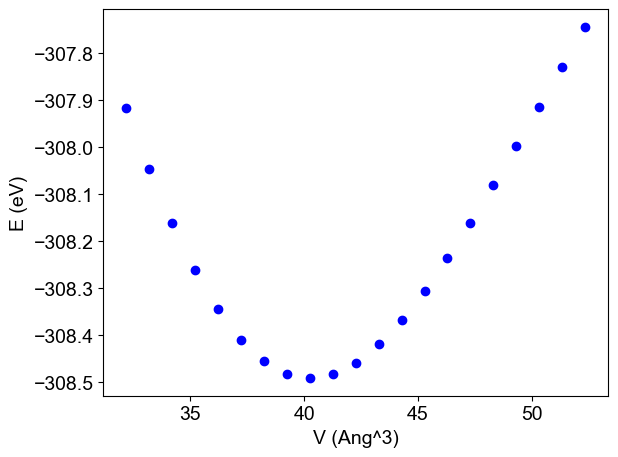

In [49]:
fig, ax = plt.subplots(1,1)

# --- Energies
ax.plot(volumes, energies, 'bo')

ax.set_xlabel('V (Ang^3)')
ax.set_ylabel('E (eV)')

fig.tight_layout()
plt.show()

## Phonons using Phonopy and FLARE

In [50]:
def run_phonons(atoms, filename: str = None):
    """Run phonons using Phonopy."""
    from ase.atoms import Atoms
    from phonopy import Phonopy
    from phonopy.structure.atoms import PhonopyAtoms

    # ================================= INPUTS ======================================= #
    supercell_size = 4
    distance = 0.01 # in Angstrom
    symmetrize = False
    conventional = True
    primitive_matrix = None
    # primitive_matrix = 'auto'
    # ================================================================================ #

    supercell_matrix = [supercell_size]*3
    if conventional:
        supercell_matrix = np.dot(supercell_size*np.eye(3), -np.array([[1,1,-1],[1,-1,1],[-1,1,1]]) ) # conventional cell

    unitcell = PhonopyAtoms(
        symbols=atoms.get_chemical_symbols(),
        numbers=atoms.get_atomic_numbers(),
        scaled_positions=atoms.get_scaled_positions(),
        cell=atoms.get_cell(),
        pbc=True,
    )

    ph = Phonopy(
        unitcell=unitcell,
        primitive_matrix=primitive_matrix,
        supercell_matrix=supercell_matrix,
    )

    ph.generate_displacements(distance=distance)    
    supercells = ph.supercells_with_displacements

    sets_of_forces = []
    for supercell in supercells:
        cell, scaled_positions, numbers = supercell.totuple()
        supercell_atoms = Atoms(
            cell=cell,
            scaled_positions=scaled_positions,
            numbers=numbers,
            calculator=flare_calc
        )
        sets_of_forces.append(supercell_atoms.get_forces())

    ph.forces = sets_of_forces
    ph.produce_force_constants()
    return ph

/tmp/ipykernel_71403/3093414531.py:20: DeprecationWarning: PhonopyAtoms.__init__ parameter of pbc is deprecated. It is considered always True.
  unitcell = PhonopyAtoms(
/opt/conda/lib/python3.10/site-packages/seekpath/hpkot/__init__.py:156: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  conv_lattice = dataset['std_lattice']


<module 'matplotlib.pyplot' from '/opt/conda/lib/python3.10/site-packages/matplotlib/pyplot.py'>

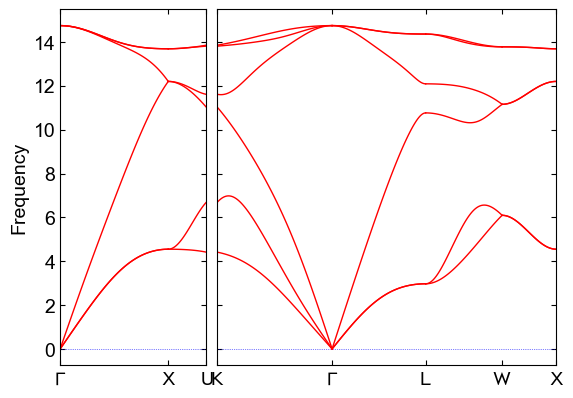

In [51]:
scaled_atoms = atoms.copy()
ph = run_phonons(atoms)
ph.auto_band_structure(plot=True)

## Quasi-harmonic approximation

In [52]:
def run_phonons(atoms, filename: str = None):
    """Run phonons using Phonopy."""
    from ase.atoms import Atoms
    from phonopy import Phonopy
    from phonopy.structure.atoms import PhonopyAtoms

    # ================================= INPUTS ======================================= #
    supercell_size = 4
    distance = 0.01 # in Angstrom
    t_min = 0   # Kelvin
    t_max = 300 # Kelvin
    symmetrize = False
    conventional = True
    primitive_matrix = None
    thermal_properties = True
    # primitive_matrix = 'auto'
    # ================================================================================ #

    supercell_matrix = [supercell_size]*3
    if conventional:
        supercell_matrix = np.dot(supercell_size*np.eye(3), -np.array([[1,1,-1],[1,-1,1],[-1,1,1]]) ) # conventional cell

    unitcell = PhonopyAtoms(
        symbols=atoms.get_chemical_symbols(),
        numbers=atoms.get_atomic_numbers(),
        scaled_positions=atoms.get_scaled_positions(),
        cell=atoms.get_cell(),
    )

    ph = Phonopy(
        unitcell=unitcell,
        primitive_matrix=primitive_matrix,
        supercell_matrix=supercell_matrix,
    )

    ph.generate_displacements(distance=distance)
    supercells = ph.supercells_with_displacements

    sets_of_forces = []
    for supercell in supercells:
        cell, scaled_positions, numbers = supercell.totuple()
        supercell_atoms = Atoms(
            cell=cell,
            scaled_positions=scaled_positions,
            numbers=numbers,
            calculator=flare_calc
        )
        sets_of_forces.append(supercell_atoms.get_forces())

    ph.forces = sets_of_forces
    ph.produce_force_constants()

    if symmetrize:
        ph.symmetrize_force_constants()
        ph.symmetrize_force_constants_by_space_group()
        
    if thermal_properties:
        ph.run_mesh(mesh=100)
        ph.run_thermal_properties(t_min=t_min, t_max=t_max)
        ph.thermal_properties.write_yaml(filename)

In [53]:
start_index = -energies.index(min(energies))
for scale_factor in scale_factors:
    scaled_atoms = scale_and_relax(atoms, scale_factor)
    run_phonons(scaled_atoms, filename=f'./thermal_properties.yaml-{start_index}')
    start_index += 1

      Step     Time          Energy         fmax
BFGS:    0 08:48:15     -307.917760        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:48:18     -308.047158        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:48:21     -308.162612        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:48:24     -308.262466        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:48:27     -308.345277        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:48:30     -308.409976        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:48:34     -308.455967        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:48:37     -308.483180        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:48:40     -308.492068        0.0000
      Step     Time          Energy         fmax
BFGS:    0 08:48:43     -308.483570        0.0000
      Step